# Importing Required Libraries

In [1]:
# Visualization 
import matplotlib.pyplot as plt
import seaborn as sns

# Audio specific packages
import librosa
from IPython.display import Audio, display

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchaudio
import torch.optim as optim 
import torchaudio.functional as F
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

from glob import glob
import random
from tqdm import tqdm
import soundfile as sf

import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import os

from sklearn.metrics import f1_score , accuracy_score, classification_report, confusion_matrix
import math

device: cuda


# WandB setup

In [2]:
!pip install --upgrade wandb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.3/25.3 MB 54.0 MB/s eta 0:00:00:00:0100:01


In [3]:
import wandb
wandb.login()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 23f3003877 (23F3003877-t12026) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

# Data Loader

In [4]:
# creating a dataset class to use pre-created mel-spectrogram of audio mashup
class MelSpectrogramDataset(Dataset):
    def __init__(self, is_validation, train_paths,val_path):
        """
        is_validation: True for validation data
        train_paths: list of paths for training data
        val_path: Path to the root folder containing genre subfolders for validations
        """
        self.is_validation = is_validation
        self.train_paths = train_paths
        self.val_path = val_path
        self.genre_to_label = {
            "blues": 0, "classical": 1, "country": 2, "disco": 3, "hiphop": 4,
            "jazz": 5, "metal": 6, "pop": 7, "reggae": 8, "rock": 9
        }
        
        self.samples = []   

        if self.is_validation:
            for genre, label in self.genre_to_label.items():
                genre_path = os.path.join(val_path, genre, "*.npz")
                all_files = sorted(glob(genre_path))
                
                # Store pairs of (path, label)
                for f in all_files:
                    self.samples.append((f, label))
        else:
            for path in train_paths:
                for genre, label in self.genre_to_label.items():
                    genre_path = os.path.join(path, genre, "*.npz")
                    all_files = sorted(glob(genre_path))
                    
                    # Store pairs of (path, label)
                    for f in all_files:
                        self.samples.append((f, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        file_path, label = self.samples[index]
        
        with np.load(file_path) as data:
            mel = data['mel_spectrogram']

        mel_tensor = torch.from_numpy(mel).float()
            
        if not self.is_validation:
            if random.random() > 0.5:
                mel_tensor = F.mask_along_axis(
                    mel_tensor, 
                    mask_param=10, 
                    mask_value=0, 
                    axis=0
                )
    
                mel_tensor = F.mask_along_axis(
                    mel_tensor, 
                    mask_param=10, 
                    mask_value=0, 
                    axis=1
                )
        

        # Normalization
        mean = mel_tensor.mean()
        std = mel_tensor.std()
        mel_tensor = (mel_tensor - mean)/ (std + 1e-6)


        mel_tensor = mel_tensor.unsqueeze(0)  #format channel, height, width
            
        return mel_tensor, torch.tensor(label, dtype=torch.long)

In [5]:
class test_mashed_dataset(Dataset):
    def __init__(self, path, test_csv, sr, duration):
        self.path = path
        self.test_csv = test_csv
        self.sr = sr
        self.duration = duration
        self.num_samples = int(duration * sr)

        # Mel transform
        self.mel = torchaudio.transforms.MelSpectrogram(
            sample_rate=self.sr, # number of samples per second 16000 in this case
            n_fft=400,        # 400 frequency bins the fourier tranform calculates
            win_length=400, # 25ms  # 400 samples are analyzed at one moment for creating spectrogram
            hop_length=160 , # 10ms  # 160 samples the window slides after each calculation
            n_mels=128,        # 128 frequency bands
            f_min=0,          # minimun frequency 
            f_max=8000,       # maximum frequency
            normalized=True,   # normalization
        )
        
        # self.db = torchaudio.transforms.AmplitudeToDB()

    def __len__(self):
        return len(self.test_csv)

    def __getitem__(self,index):
        filename = test_csv.iloc[index][0]
        path = self.path+filename
        
        """Load and preprocess audio."""
        audio, sr = torchaudio.load(path)
        
        if sr != self.sr:         # correct sample rate
            audio = torchaudio.functional.resample(audio, sr, self.sr)
        
        if audio.shape[0] > 1:    # ensure mono audio
            audio = audio.mean(0, keepdim=True)

        total_samples = audio.shape[-1]
        
        samples = math.ceil(total_samples/self.num_samples)

        test_data = []
                            
        for i in range(samples):  # breaking one test samples into 10.24 sec parts
            start = i*self.num_samples
            end = start+self.num_samples

            audio_chunk = audio[:,start:end]
            
            if audio_chunk.shape[-1] < self.num_samples:
                audio_chunk = torch.nn.functional.pad(audio_chunk, (0, self.num_samples- audio_chunk.shape[-1]))

            audio_mel = self.mel(audio_chunk)
            mel_db = torch.log(audio_mel + 1e-6)

            mean = mel_db.mean()
            std = mel_db.std()
            
            mel_db = (mel_db - mean) / (std + 1e-6)
                
            test_data.append(mel_db)

        return torch.stack(test_data)   # chunks, channel, height, width

In [6]:
val_path ="/kaggle/input/data-generator-ipynb/train_data/"
train_paths = [
    "/kaggle/input/data-generator-2-ipynb/train_data/",
    "/kaggle/input/data-generator-3-ipynb/train_data/",
    "/kaggle/input/data-generator-4-ipynb/train_data/",
    "/kaggle/input/data-generator-5-ipynb/train_data/"
]
test_csv = pd.read_csv("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv" , index_col='id')
sample_submission = pd.read_csv("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/sample_submission.csv" , index_col='id' )
path = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/"

In [7]:
train_dataset = MelSpectrogramDataset(False, train_paths, val_path)
val_dataset = MelSpectrogramDataset(True, train_paths, val_path)

train_loader = DataLoader(train_dataset, batch_size=124, shuffle=True, num_workers=4,pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=124, shuffle=False, num_workers=4,pin_memory=True)

test_data = test_mashed_dataset(path, test_csv, 16000, 10.24)
# batch_size 1 for test data so all audio chunk can be processed together
test_loader = DataLoader(test_data , batch_size=1, shuffle=False, num_workers=4,pin_memory=True)

# CNN 

In [8]:
class CNN_mashup_model(nn.Module):
    def __init__(self, layers, n, sr ,dr,fl):
        """
            layers: Number of CNN layer
            n: size of kernel 
            sr: sample rate of music 
            dr: dropout rate
            fl: number of start filters
        """
        super().__init__()
        self.layers = layers
        self.n = n
        self.sr = sr
        self.dr = dr


        CNN_models = []
        self.prev_channel = 1 

        for i in range(self.layers):
            
            out_channels = min(fl * (2**i), 512)
             
            CNN_models.extend([
                nn.Conv2d(in_channels=self.prev_channel, 
                          out_channels=out_channels, 
                          kernel_size=self.n, 
                          padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2),
                nn.Dropout(self.dr)
            ])
            self.prev_channel = out_channels

        self.CNN_model = nn.Sequential(*CNN_models)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()
        self.classifier = nn.Linear(in_features=self.prev_channel, out_features=10)

    def forward(self,x):
        
        x = self.CNN_model(x)
        x = self.global_pool(x)
        x = self.flatten(x)
        logits = self.classifier(x)
        
        return logits
    

In [9]:
def prediction(model,test_loader):
    model.eval()
    predictions = []
    
    with torch.inference_mode():
        for x in tqdm(test_loader):
            x = x.squeeze(0) # (batch, Num_Chunks, 1, Freq, Time) -->  (Num_Chunks, 1, Freq, Time)
            x = x.to(device)
            logits = model(x)
            avg_logits = torch.mean(logits, dim=0, keepdim=True)
            
            _, predicted_classes = torch.max(avg_logits, 1)
            predictions.append(predicted_classes.item())
            
    return predictions

In [10]:
label_to_genre = {
    0: "blues", 1: "classical", 2: "country", 3: "disco", 4: "hiphop",
    5: "jazz", 6: "metal", 7: "pop", 8: "reggae", 9: "rock"
}

In [11]:
def training_model(model, optimizer, train, val, epochs, patience, loss_fn, scheduler):
   
    patience_counter = 0   # patience counter
    best_val = 0
    best_val_preds = []
    for e in tqdm(range(epochs)):
        if patience_counter > patience:
            print(f"Early stopping triggered")
            break
        
        # training loop
        model.train()
        
        train_losses = []
        all_train_preds = []
        all_train_targets = []
        
        
        for i, (x, y ) in enumerate(train):
            
            x = x.to(device)
            y =  y.to(device)
    
            optimizer.zero_grad()
            preds = model(x)
            loss = loss_fn(preds,y)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

            _, predicted_classes = torch.max(preds, 1) 
            all_train_preds.extend(predicted_classes.cpu().numpy())
            all_train_targets.extend(y.cpu().numpy())

        train_acc = accuracy_score(all_train_targets, all_train_preds)
        train_f1 = f1_score(all_train_targets, all_train_preds, average='macro')
        avg_train_loss = np.mean(train_losses)
            
        print(f"Epoch: {e}, Training_f1_macro: {train_f1}, Training_accuracy: {train_acc}, Avg_train_loss: {avg_train_loss}")

        # validation loop
        model.eval()
        
        all_val_preds = []
        all_val_targets = []
        
        with torch.inference_mode(): 
            for x, y  in val:
                
                x = x.to(device)
                y =  y.to(device)
                
                preds = model(x)
                
                _, predicted_classes = torch.max(preds, 1)
                all_val_preds.extend(predicted_classes.cpu().numpy())
                all_val_targets.extend(y.cpu().numpy())

        val_acc = accuracy_score(all_val_targets, all_val_preds)
        val_f1 = f1_score(all_val_targets, all_val_preds, average='macro')

        scheduler.step(val_f1)
        
        print(f"Epoch: {e}, validation_f1_macro: {val_f1}, validation_accuracy: {val_acc}")

        if val_f1 > best_val:
            best_val = val_f1
            patience_counter = 0 
            torch.save(model.state_dict(), "best_model.pth")
            best_val_preds = all_val_preds
        else:
            patience_counter += 1
            print(f"Patience: {patience_counter}/{patience}")
            
        # Log metrics to wandb
        wandb.log({
                    "train/accuracy": train_acc,
                    "train/f1_macro": train_f1,
                    "train/loss": avg_train_loss,
                    "val/accuracy": val_acc,
                    "val/f1_macro": val_f1,
                    "epoch": e
                })
  
    wandb.finish()

    model.load_state_dict(torch.load('best_model.pth'))

    print(classification_report(all_val_targets,best_val_preds))
    sns.heatmap(confusion_matrix(all_val_targets,best_val_preds) , annot=True,fmt='d', cmap='Blues' )
    plt.show()
    
    return model
    

In [12]:
# wandb setup
wandb.init(
    project="Audio_Mashup",
    group="Scratch_CNN",  
    name="layer_7_kernal_3_with_512_chunks_v3", 
    config={
        "architecture": "Scratch_CNN_with_7_layers",
        "epochs": 40,
        "lr": 0.001,
        "dropout": 0.2,
        "audio_sr": 22050,
        "patience":5,
        "start_filters":32
    }
)

In [13]:
model = CNN_mashup_model(7,3,16000,0.2,32)
model.to(device)

CNN_mashup_model(
  (CNN_model): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.2, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout(p=0.2, inplace=False)
    (15): Conv2d(128, 256, kernel_size=(

# Model traning

  0%|          | 0/40 [00:00<?, ?it/s]

Epoch: 0, Training_f1_macro: 0.716910042446588, Training_accuracy: 0.7187509211857995, Avg_train_loss: 0.7893254269418124


  2%|▎         | 1/40 [09:17<6:02:12, 557.25s/it]

Epoch: 0, validation_f1_macro: 0.5645691569994046, validation_accuracy: 0.5761040389753261
Epoch: 1, Training_f1_macro: 0.8616041092992026, Training_accuracy: 0.8620628666319482, Avg_train_loss: 0.39834586470121297


  5%|▌         | 2/40 [18:00<5:40:26, 537.53s/it]

...

Epoch: 28, validation_f1_macro: 0.9853659277968534, validation_accuracy: 0.9853449630677353
Patience: 5/5
Epoch: 29, Training_f1_macro: 0.9987511333391359, Training_accuracy: 0.9987521003036228, Avg_train_loss: 0.004694944704615088


 75%|███████▌  | 30/40 [4:23:23<1:27:47, 526.79s/it]

Epoch: 29, validation_f1_macro: 0.9860274842458713, validation_accuracy: 0.9860128870029861
Patience: 6/5
Early stopping triggered


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train/accuracy,▁▅▆▆▇▇▇▇▇▇▇███████████████████
train/f1_macro,▁▅▆▆▇▇▇▇▇▇▇███████████████████
train/loss,█▅▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▃▅▆▇▇▇▇▇▇▇███████████████████
val/f1_macro,▁▃▅▆▇▇▇▇▇▇▇███████████████████
epoch,29
train/accuracy,0.99875
train/f1_macro,0.99875
train/loss,0.00469
val/accuracy,0.98601


              precision    recall  f1-score   support

           0       0.99      0.98      0.99      2544
           1       0.99      1.00      0.99      2537
           2       0.97      0.99      0.98      2540
           3       0.99      0.99      0.99      2547
           4       1.00      0.98      0.99      2544
           5       0.99      0.99      0.99      2542
           6       0.99      0.99      0.99      2547
           7       0.99      0.98      0.98      2549
           8       0.99      0.99      0.99      2544
           9       0.97      0.97      0.97      2558

    accuracy                           0.99     25452
   macro avg       0.99      0.99      0.99     25452
weighted avg       0.99      0.99      0.99     25452



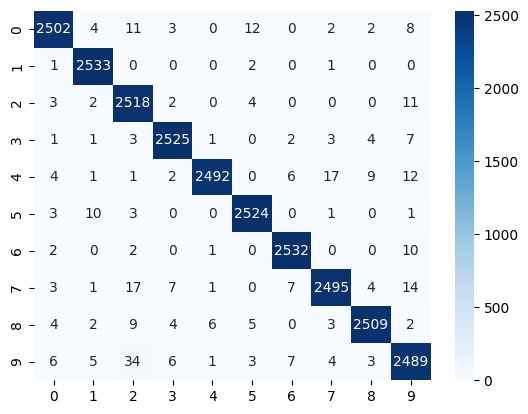

In [14]:
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
loss_fn = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

model_trained = training_model(model, optimizer, train_loader, val_loader, 40, 5, loss_fn, scheduler )

# Final prediction on test data

In [15]:
preds = prediction(model_trained,test_loader)
sample_submission['genre'] = [label_to_genre[i] for i in preds]

100%|██████████| 3020/3020 [01:10<00:00, 42.65it/s]


In [16]:
sample_submission.to_csv("submission.csv")

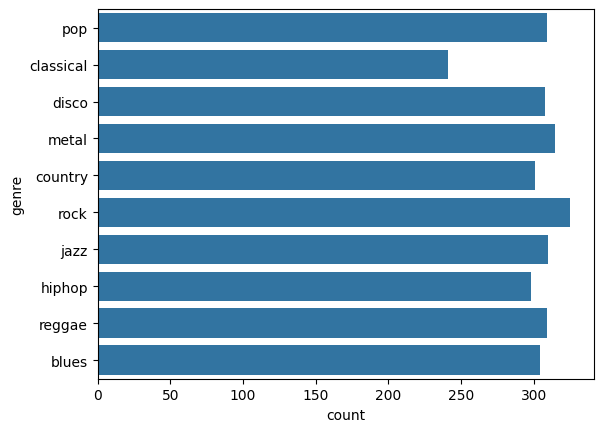

In [6]:
sns.countplot(sample_submission['genre'])
plt.show()

In [18]:
import kagglehub

MODEL_UPLOAD_DIR = "/kaggle/working/Scratch_CNN" 
os.makedirs(MODEL_UPLOAD_DIR, exist_ok=True)

MODEL_SAVE_PATH = os.path.join(MODEL_UPLOAD_DIR, "Scratch_CNN.pth")
torch.save(model_trained.state_dict(), MODEL_SAVE_PATH)     # model_trained
print(f"Model saved to {MODEL_SAVE_PATH}")

KAGGLE_USERNAME = 'aryanchauhan97971234' 
MODEL = 'Scratch_CNN_3_4_V3'
FRAMEWORK = 'pytorch'
VARIATION = '7_3_22050_0.2_32'

handle = f'{KAGGLE_USERNAME}/{MODEL}/{FRAMEWORK}/{VARIATION}'

print(f"Uploading model from {MODEL_UPLOAD_DIR} to {handle}...")

kagglehub.model_upload(
    handle,                     
    MODEL_UPLOAD_DIR,           
    license_name="Apache 2.0", 
    version_notes="4th run with transfer, lr scheduler"
)
print("Upload complete!")

Model saved to /kaggle/working/Scratch_CNN/Scratch_CNN.pth
Uploading model from /kaggle/working/Scratch_CNN to aryanchauhan97971234/Scratch_CNN_3_4_V3/pytorch/7_3_22050_0.2_32...
Uploading Model https://api.kaggle.com/models/aryanchauhan97971234/Scratch_CNN_3_4_V3/pytorch/7_3_22050_0.2_32 ...
Model 'Scratch_CNN_3_4_V3' does not exist or access is forbidden for user 'aryanchauhan97971234'. Creating or handling Model...
Starting upload for file /kaggle/working/Scratch_CNN/Scratch_CNN.pth


Uploading: 100%|██████████| 25.2M/25.2M [00:00<00:00, 42.2MB/s]

Upload successful: /kaggle/working/Scratch_CNN/Scratch_CNN.pth (24MB)


Your model instance has been created.
Files are being processed...
See at: https://api.kaggle.com/models/aryanchauhan97971234/Scratch_CNN_3_4_V3/pytorch/7_3_22050_0.2_32
Upload complete!
